# Credit Risk Analysis

## Project Overview

This project analyzes borrower and loan-related data to identify patterns associated with loan defaults.

The analysis focuses on factors such as loan grade, loan amount, interest rate, loan-to-income burden, previous default history, income, employment length, loan purpose, and home ownership.

## Project Objective

The main objective of this project is to understand borrower risk patterns and identify factors that are associated with higher observed default rates.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset Information

The dataset contains information about borrowers, their income, employment history, loan details, credit history, and loan repayment status.

### Dataset Size

- Rows: 32,581
- Columns: 12

### Target Variable

- `loan_status`
  - 0 = Loan not defaulted
  - 1 = Loan defaulted

### Main Features

- `person_age` — Borrower's age
- `person_income` — Borrower's annual income
- `person_home_ownership` — Home ownership status
- `person_emp_length` — Employment length
- `loan_intent` — Purpose of the loan
- `loan_grade` — Loan risk grade
- `loan_amnt` — Loan amount
- `loan_int_rate` — Interest rate
- `loan_percent_income` — Loan amount as a percentage of income
- `cb_person_default_on_file` — Previous default record
- `cb_person_cred_hist_length` — Credit history length

## Data Cleaning Summary

The dataset was checked for missing values, duplicate records, and invalid values before performing the analysis.

### Cleaning Steps

- Missing values in `person_age`, `person_emp_length`, and `loan_int_rate` were handled using median values.
- Invalid age values above 100 were treated as missing and replaced with the median age.
- Invalid employment length values above 100 were treated as missing and replaced with the median employment length.
- Missing interest rates were replaced with the median interest rate.
- Duplicate records were checked and no duplicate rows were found in the final dataset.
- The original dataset was preserved, and cleaning was performed on a copy.
- Final dataset contains 32,581 rows and 12 columns.
- Final missing-value check showed zero missing values.

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [141]:
df =  pd.read_csv("credit_risk_dataset.csv")
df_clean = df.copy()

In [142]:
df.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [143]:
df.shape

(32581, 12)

In [144]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [146]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [147]:
missing_percent = (df.isnull().sum()/len(df))*100

In [148]:
missing_percent

,0
person_age,0.000000
person_income,0.000000
person_home_ownership,0.000000
person_emp_length,2.747000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_int_rate,9.563856
loan_status,0.000000
loan_percent_income,0.000000


In [149]:
df.duplicated().sum()

np.int64(165)

In [150]:
df[df.duplicated()].head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15975,23,42000,RENT,5.0,VENTURE,B,6000,9.99,0,0.14,N,4
15989,23,90000,MORTGAGE,7.0,EDUCATION,B,8000,10.36,0,0.09,N,3
15995,24,48000,MORTGAGE,4.0,MEDICAL,A,4000,5.42,0,0.08,N,4
16025,24,10000,RENT,8.0,PERSONAL,A,3000,7.90,1,0.30,N,3
16028,23,100000,MORTGAGE,7.0,EDUCATION,A,15000,7.88,0,0.15,N,4


In [151]:

df.shape

(32581, 12)

In [152]:



df[df.duplicated(keep=False)].sort_values(
    by=['person_age', 'person_income']
).head(20)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15944,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2
16835,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2
2431,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4
17758,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4
2498,21,18000,RENT,0.0,DEBTCONSOLIDATION,A,3000,7.90,1,0.17,N,2
17601,21,18000,RENT,0.0,DEBTCONSOLIDATION,A,3000,7.90,1,0.17,N,2
1778,21,20000,RENT,0.0,MEDICAL,A,2000,NaN,0,0.10,N,3
17642,21,20000,RENT,0.0,MEDICAL,A,2000,NaN,0,0.10,N,3
740,21,21600,OWN,NaN,VENTURE,A,7125,6.99,0,0.33,N,3
17283,21,21600,OWN,NaN,VENTURE,A,7125,6.99,0,0.33,N,3


In [153]:
df.shape

(32581, 12)

In [154]:
df.duplicated(keep=False).sum()

np.int64(330)

In [155]:
df['person_emp_length'].describe()

,person_emp_length
count,31686.000000
mean,4.789686
std,4.142630
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,123.000000


In [156]:
df.shape

(32581, 12)

In [157]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [158]:
df[df['person_emp_length'] > 40]['person_emp_length'].value_counts().sort_index()

,count
person_emp_length,
41.0,1
123.0,2


In [159]:
df[df['person_emp_length'] > 40][
    ['person_age', 'person_income', 'person_emp_length',
     'loan_amnt', 'loan_status']
]

,person_age,person_income,person_emp_length,loan_amnt,loan_status
0,22,59000,123.0,35000,1
210,21,192000,123.0,20000,0
32355,78,48000,41.0,3000,0


In [160]:
df[df['person_emp_length'] > df['person_age']][
    ['person_age', 'person_emp_length']
]

,person_age,person_emp_length
0,22,123.0
210,21,123.0


In [161]:
df_clean.loc[df_clean['person_emp_length'] == 123, 'person_emp_length'] = np.nan


In [162]:
df_clean['person_emp_length'].describe()

,person_emp_length
count,31684.000000
mean,4.782224
std,4.034888
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,41.000000


In [163]:
df_clean['person_emp_length'].isnull().sum()

np.int64(897)

In [164]:
df_clean['loan_int_rate'].describe()

,loan_int_rate
count,29465.000000
mean,11.011695
std,3.240459
min,5.420000
25%,7.900000
50%,10.990000
75%,13.470000
max,23.220000


In [165]:
df_clean.groupby('loan_grade')['loan_int_rate'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
loan_grade,,,,,
A,9774,7.327651,7.490,5.42,9.63
B,9395,10.995555,10.990,6.00,12.69
C,5828,13.463542,13.480,6.00,16.11
D,3314,15.361448,15.310,6.00,18.49
E,881,17.009455,16.820,6.00,20.69
F,214,18.609159,18.535,15.01,22.06
G,59,20.251525,20.160,17.34,23.22


In [166]:
missing_by_grade = df_clean.groupby('loan_grade')['loan_int_rate'].agg(
    total='size',
    missing=lambda x: x.isna().sum()
)

missing_by_grade['missing_pct'] = (
    missing_by_grade['missing'] / missing_by_grade['total'] * 100
)

missing_by_grade

,total,missing,missing_pct
loan_grade,,,
A,10777,1003,9.306857
B,10451,1056,10.104296
C,6458,630,9.755342
D,3626,312,8.604523
E,964,83,8.609959
F,241,27,11.203320
G,64,5,7.812500


In [167]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [168]:
df.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [169]:
df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


In [170]:
df['loan_status'].value_counts(normalize=True)*100

,proportion
loan_status,
0,78.183604
1,21.816396


In [171]:
df.groupby('loan_grade')['loan_status'].mean()*100

,loan_status
loan_grade,
A,9.956389
B,16.275954
C,20.733973
D,59.045780
E,64.419087
F,70.539419
G,98.437500


In [172]:
grade_risk = df.groupby('loan_grade').agg(
    total_loans=('loan_status', 'count'),
    default_loans=('loan_status', 'sum'),
    default_rate=('loan_status', 'mean')
)

grade_risk['default_rate'] = grade_risk['default_rate'] * 100

grade_risk

,total_loans,default_loans,default_rate
loan_grade,,,
A,10777,1073,9.956389
B,10451,1701,16.275954
C,6458,1339,20.733973
D,3626,2141,59.045780
E,964,621,64.419087
F,241,170,70.539419
G,64,63,98.437500


In [173]:
df['loan_int_rate'].describe()

,loan_int_rate
count,29465.000000
mean,11.011695
std,3.240459
min,5.420000
25%,7.900000
50%,10.990000
75%,13.470000
max,23.220000


In [174]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [175]:
df.groupby(
    pd.qcut(df['loan_int_rate'], 5)
)['loan_status'].mean() * 100

/tmp/ipykernel_1284/1823141477.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


,loan_status
loan_int_rate,
"(5.419, 7.51]",8.743351
"(7.51, 10.25]",13.510354
"(10.25, 11.86]",16.577263
"(11.86, 13.92]",20.657035
"(13.92, 23.22]",50.613497


In [176]:
df['person_income'].describe()

,person_income
count,3.258100e+04
mean,6.607485e+04
std,6.198312e+04
min,4.000000e+03
25%,3.850000e+04
50%,5.500000e+04
75%,7.920000e+04
max,6.000000e+06


In [177]:
df.groupby(
    pd.qcut(df['person_income'], 5)
)['loan_status'].mean() * 100

/tmp/ipykernel_1284/95404680.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


,loan_status
person_income,
"(3999.999, 35000.0]",43.257919
"(35000.0, 49000.0]",23.449435
"(49000.0, 63000.0]",18.196029
"(63000.0, 86000.0]",14.551036
"(86000.0, 6000000.0]",9.132912


In [178]:
df.groupby('loan_intent')['loan_status'].mean() * 100

,loan_status
loan_intent,
DEBTCONSOLIDATION,28.587874
EDUCATION,17.216798
HOMEIMPROVEMENT,26.102635
MEDICAL,26.700708
PERSONAL,19.887702
VENTURE,14.810282


In [179]:
df['cb_person_default_on_file'].value_counts()

,count
cb_person_default_on_file,
N,26836
Y,5745


In [180]:
df.groupby('cb_person_default_on_file')['loan_status'].mean()*100

,loan_status
cb_person_default_on_file,
N,18.393203
Y,37.806789


In [181]:
df['cb_person_cred_hist_length'].describe()

,cb_person_cred_hist_length
count,32581.000000
mean,5.804211
std,4.055001
min,2.000000
25%,3.000000
50%,4.000000
75%,8.000000
max,30.000000


In [182]:
df.groupby('cb_person_cred_hist_length')['loan_status'].mean() * 100

,loan_status
cb_person_cred_hist_length,
2,23.570830
3,22.278311
4,22.312236
5,20.627326
6,20.786214
7,19.936875
8,21.345952
9,20.844327
10,20.270270


In [183]:
df['loan_amnt'].describe()

,loan_amnt
count,32581.000000
mean,9589.371106
std,6322.086646
min,500.000000
25%,5000.000000
50%,8000.000000
75%,12200.000000
max,35000.000000


In [184]:
df['loan_amount_group'] = pd.qcut(
    df['loan_amnt'],
    q=5
)

df.groupby('loan_amount_group')['loan_status'].mean() * 100

/tmp/ipykernel_1284/1594128403.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('loan_amount_group')['loan_status'].mean() * 100


,loan_status
loan_amount_group,
"(499.999, 4400.0]",20.953691
"(4400.0, 6750.0]",17.295549
"(6750.0, 10000.0]",18.980337
"(10000.0, 14500.0]",21.824962
"(14500.0, 35000.0]",30.910211


In [185]:
df.drop(columns='loan_amount_group', inplace=True)

In [186]:
df['loan_percent_income'].describe()

,loan_percent_income
count,32581.000000
mean,0.170203
std,0.106782
min,0.000000
25%,0.090000
50%,0.150000
75%,0.230000
max,0.830000


In [187]:
df['loan_income_group'] = pd.qcut(
    df['loan_percent_income'],
    q=5
)

df.groupby('loan_income_group')['loan_status'].mean() * 100

/tmp/ipykernel_1284/1940661376.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('loan_income_group')['loan_status'].mean() * 100


,loan_status
loan_income_group,
"(-0.001, 0.08]",11.410460
"(0.08, 0.12]",12.459721
"(0.12, 0.18]",15.170911
"(0.18, 0.25]",19.137931
"(0.25, 0.83]",52.929936


In [188]:
df.drop(columns='loan_income_group', inplace=True)

In [189]:
df['person_age'].describe()

,person_age
count,32581.000000
mean,27.734600
std,6.348078
min,20.000000
25%,23.000000
50%,26.000000
75%,30.000000
max,144.000000


In [190]:
df[df['person_age'] > 80]['person_age'].value_counts().sort_index()

,count
person_age,
84,1
94,1
123,2
144,3


In [191]:
df[df['person_age'] > 80][
    ['person_age', 'person_income', 'loan_amnt', 'loan_status']
]

,person_age,person_income,loan_amnt,loan_status
81,144,250000,4800,0
183,144,200000,6000,0
575,123,80004,20400,0
747,123,78000,20000,0
32297,144,6000000,5000,0
32416,94,24000,6500,0
32506,84,94800,10000,0


In [192]:
(df['person_age'] <= 80).sum()
(df['person_age'] > 80).sum()

np.int64(7)

In [193]:
df['person_emp_length'].describe()

,person_emp_length
count,31686.000000
mean,4.789686
std,4.142630
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,123.000000


In [194]:
df[df['person_emp_length'] > 40]['person_emp_length'].value_counts().sort_index()


,count
person_emp_length,
41.0,1
123.0,2


In [195]:
df[df['person_emp_length'] > 40][
    ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_status']
]

,person_age,person_income,person_emp_length,loan_amnt,loan_status
0,22,59000,123.0,35000,1
210,21,192000,123.0,20000,0
32355,78,48000,41.0,3000,0


In [196]:
df['person_emp_length'].isna().sum()

np.int64(895)

In [197]:
df[df['person_age'] > 80][
    ['person_age', 'person_income', 'loan_amnt', 'loan_status']
]

,person_age,person_income,loan_amnt,loan_status
81,144,250000,4800,0
183,144,200000,6000,0
575,123,80004,20400,0
747,123,78000,20000,0
32297,144,6000000,5000,0
32416,94,24000,6500,0
32506,84,94800,10000,0


In [198]:
df[df['person_income'] > 500000][
    ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_status']
]

,person_age,person_income,person_emp_length,loan_amnt,loan_status
17833,32,1200000,1.0,12000,0
17834,34,948000,18.0,2000,0
17840,35,648000,6.0,10000,1
17846,30,504000,4.0,3000,0
18635,31,636000,2.0,17500,0
18917,35,510000,1.0,1800,0
21462,33,612000,3.0,5950,0
21958,34,564000,2.0,6000,0
23429,31,552000,0.0,8000,0
23431,30,648000,NaN,8000,0


In [199]:

df[df['loan_int_rate'].notna()]['loan_int_rate'].describe()

,loan_int_rate
count,29465.000000
mean,11.011695
std,3.240459
min,5.420000
25%,7.900000
50%,10.990000
75%,13.470000
max,23.220000


In [200]:
df['loan_percent_income'].describe()

,loan_percent_income
count,32581.000000
mean,0.170203
std,0.106782
min,0.000000
25%,0.090000
50%,0.150000
75%,0.230000
max,0.830000


In [201]:


df['cb_person_cred_hist_length'].describe()

,cb_person_cred_hist_length
count,32581.000000
mean,5.804211
std,4.055001
min,2.000000
25%,3.000000
50%,4.000000
75%,8.000000
max,30.000000


In [202]:
df['loan_grade'].value_counts(dropna=False).sort_index()

,count
loan_grade,
A,10777
B,10451
C,6458
D,3626
E,964
F,241
G,64


In [203]:
df_clean = df.copy()


In [204]:
df_clean.loc[df_clean['person_age'] > 100, 'person_age']

,person_age
81,144
183,144
575,123
747,123
32297,144


In [205]:
df_clean['person_age'].isna().sum()

np.int64(0)

In [206]:
df_clean.loc[df_clean['person_emp_length'] > 100, 'person_emp_length'] = np.nan

In [207]:
df_clean.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,897
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [208]:
df_clean[['person_age', 'person_emp_length', 'loan_int_rate']].median()

,0
person_age,26.00
person_emp_length,4.00
loan_int_rate,10.99


In [209]:
df_clean['person_age'] = df_clean['person_age'].fillna(26)

df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(4)

df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(10.99)

In [210]:
df_clean.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [211]:
df_clean.shape

(32581, 12)

In [212]:
grade_default_rate = df_clean.groupby('loan_grade')['loan_status'].mean() * 100

grade_default_rate

,loan_status
loan_grade,
A,9.956389
B,16.275954
C,20.733973
D,59.045780
E,64.419087
F,70.539419
G,98.437500


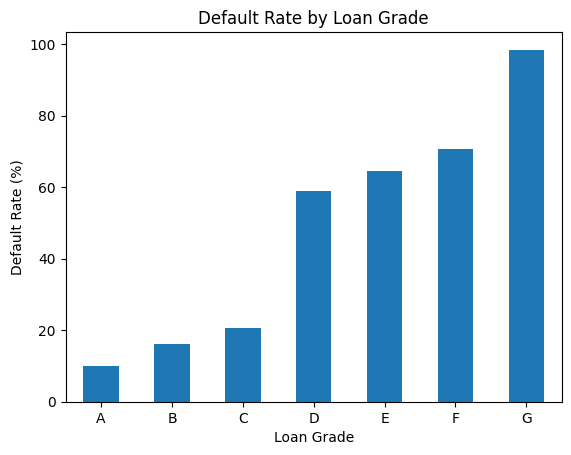

In [213]:
import matplotlib.pyplot as plt

grade_default_rate.plot(kind='bar')

plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [214]:
intent_default_rate = df_clean.groupby('loan_intent')['loan_status'].mean() * 100

intent_default_rate

,loan_status
loan_intent,
DEBTCONSOLIDATION,28.587874
EDUCATION,17.216798
HOMEIMPROVEMENT,26.102635
MEDICAL,26.700708
PERSONAL,19.887702
VENTURE,14.810282


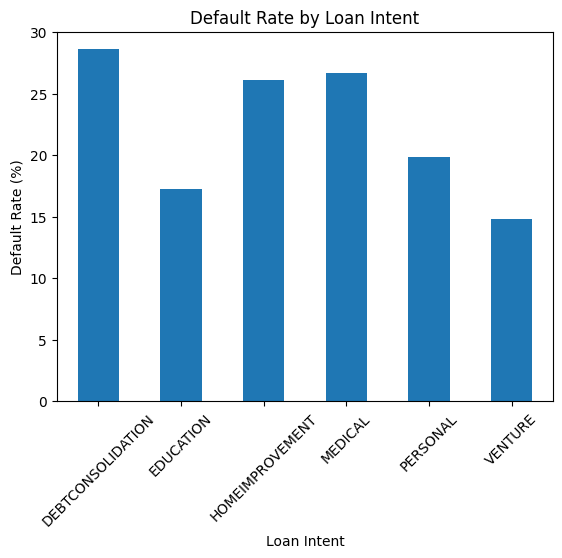

In [215]:
intent_default_rate.plot(kind='bar')

plt.title('Default Rate by Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [216]:
home_default_rate = df_clean.groupby('person_home_ownership')['loan_status'].mean() * 100

home_default_rate

,loan_status
person_home_ownership,
MORTGAGE,12.570663
OTHER,30.841121
OWN,7.469040
RENT,31.569987


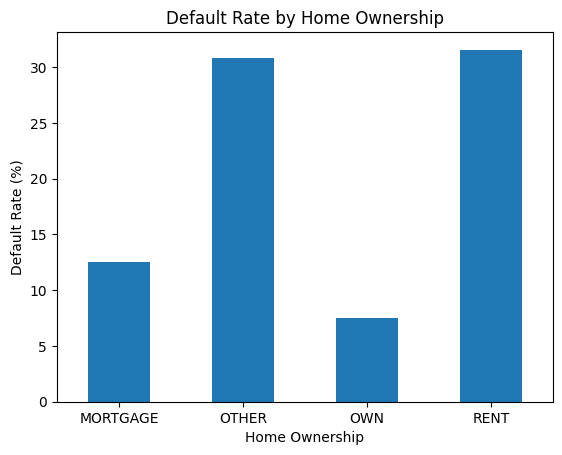

In [217]:
home_default_rate.plot(kind='bar')

plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [218]:
previous_default_rate = df_clean.groupby('cb_person_default_on_file')['loan_status'].mean() * 100

previous_default_rate

,loan_status
cb_person_default_on_file,
N,18.393203
Y,37.806789


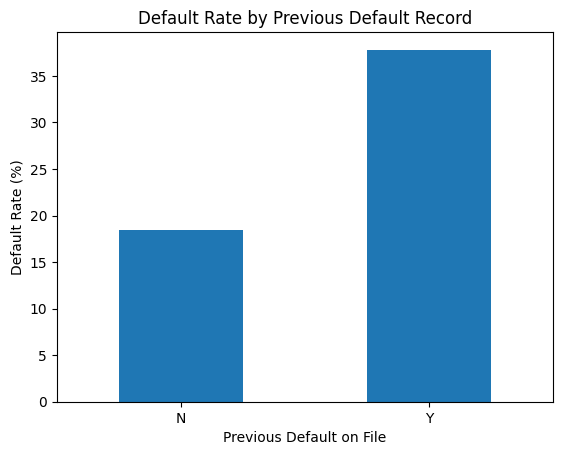

In [219]:
previous_default_rate.plot(kind='bar')

plt.title('Default Rate by Previous Default Record')
plt.xlabel('Previous Default on File')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [220]:
loan_income_group = pd.qcut(
    df_clean['loan_percent_income'],
    q=5
)

loan_income_default_rate = df_clean.groupby(
    loan_income_group,
    observed=True
)['loan_status'].mean() * 100

loan_income_default_rate

,loan_status
loan_percent_income,
"(-0.001, 0.08]",11.410460
"(0.08, 0.12]",12.459721
"(0.12, 0.18]",15.170911
"(0.18, 0.25]",19.137931
"(0.25, 0.83]",52.929936


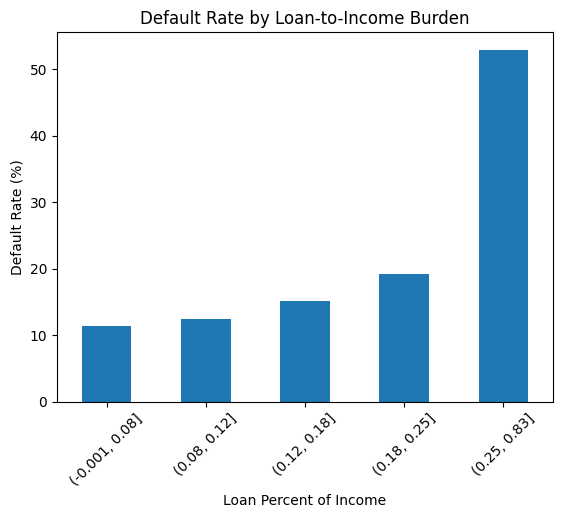

In [221]:
loan_income_default_rate.plot(kind='bar')

plt.title('Default Rate by Loan-to-Income Burden')
plt.xlabel('Loan Percent of Income')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [222]:
interest_rate_group = pd.qcut(
    df_clean['loan_int_rate'],
    q=5
)

interest_default_rate = df_clean.groupby(
    interest_rate_group,
    observed=True
)['loan_status'].mean() * 100

interest_default_rate

,loan_status
loan_int_rate,
"(5.419, 7.74]",8.833001
"(7.74, 10.59]",14.165261
"(10.59, 11.49]",18.370064
"(11.49, 13.61]",19.880466
"(13.61, 23.22]",48.332814


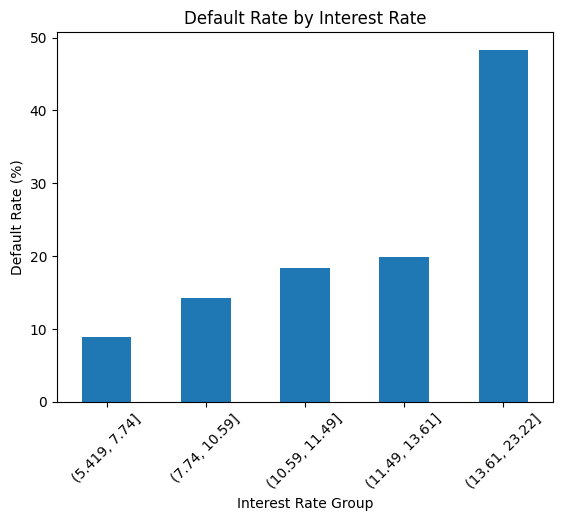

In [223]:
interest_default_rate.plot(kind='bar')

plt.title('Default Rate by Interest Rate')
plt.xlabel('Interest Rate Group')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [224]:
numeric_cols = df_clean.select_dtypes(include='number').columns

numeric_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

In [225]:
correlation_matrix = df_clean[numeric_cols].corr()

correlation_matrix

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.167570,0.050787,0.011853,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.137016,0.266820,0.000746,-0.144449,-0.254471,0.117987
person_emp_length,0.167570,0.137016,1.000000,0.111694,-0.052793,-0.085630,-0.058584,0.147934
loan_amnt,0.050787,0.266820,0.111694,1.000000,0.139483,0.105376,0.572612,0.041967
loan_int_rate,0.011853,0.000746,-0.052793,0.139483,1.000000,0.319360,0.114514,0.015762
loan_status,-0.021629,-0.144449,-0.085630,0.105376,0.319360,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.058584,0.572612,0.114514,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.147934,0.041967,0.015762,-0.015529,-0.031690,1.000000


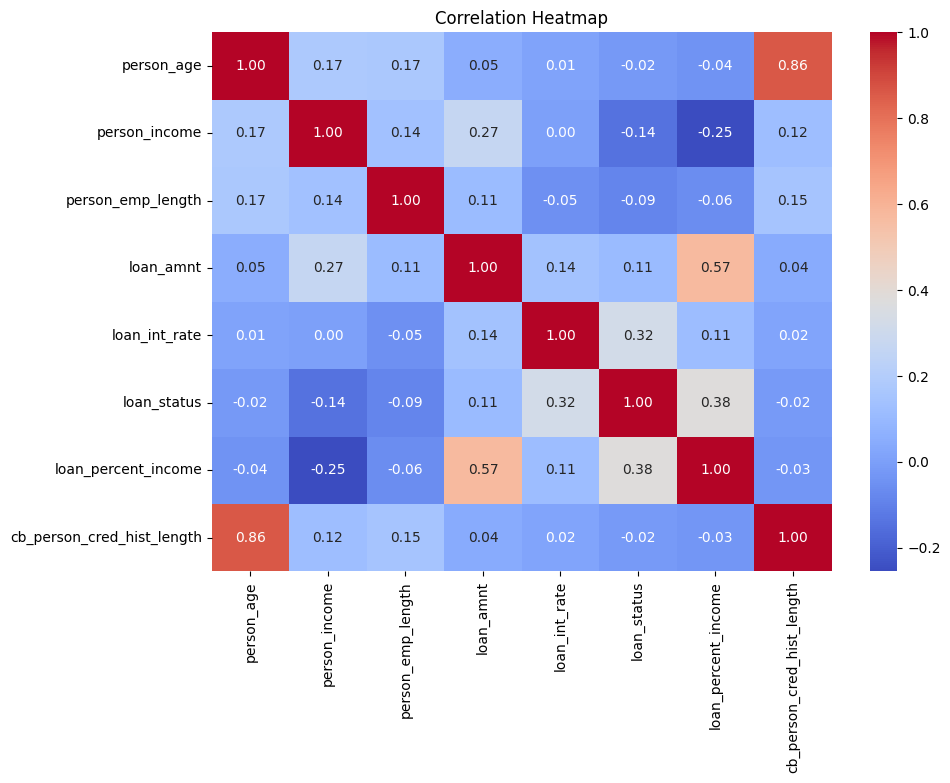

In [226]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [227]:
insights = [
    "Higher loan-to-income burden was associated with higher default rates.",
    "Higher interest-rate groups showed higher default rates.",
    "Default rates increased substantially from Loan Grade A to Grade G.",
    "Higher income showed a weak negative relationship with default status.",
    "Borrowers with a previous default record had a higher current default rate.",
    "Default rates varied across different home ownership categories.",
    "Default rates differed across loan purposes.",
    "Age showed almost no linear relationship with default status."
]

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

1. Higher loan-to-income burden was associated with higher default rates.
2. Higher interest-rate groups showed higher default rates.
3. Default rates increased substantially from Loan Grade A to Grade G.
4. Higher income showed a weak negative relationship with default status.
5. Borrowers with a previous default record had a higher current default rate.
6. Default rates varied across different home ownership categories.
7. Default rates differed across loan purposes.
8. Age showed almost no linear relationship with default status.


In [228]:
df_clean.shape

(32581, 12)

In [229]:
df_clean.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,4.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [230]:
high_risk_grade = df_clean[df_clean['loan_grade'].isin(['D', 'E', 'F', 'G'])]

high_risk_grade.shape

(4895, 12)

In [231]:
high_risk_grade_default_rate = high_risk_grade['loan_status'].mean() * 100

high_risk_grade_default_rate

np.float64(61.18488253319714)

In [232]:
risk_group = df_clean['loan_grade'].apply(
    lambda x: 'High Risk (D-G)' if x in ['D', 'E', 'F', 'G']
    else 'Lower Risk (A-C)'
)

risk_group_default_rate = df_clean.groupby(
    risk_group
)['loan_status'].mean() * 100

risk_group_default_rate

,loan_status
loan_grade,
High Risk (D-G),61.184883
Lower Risk (A-C),14.855884


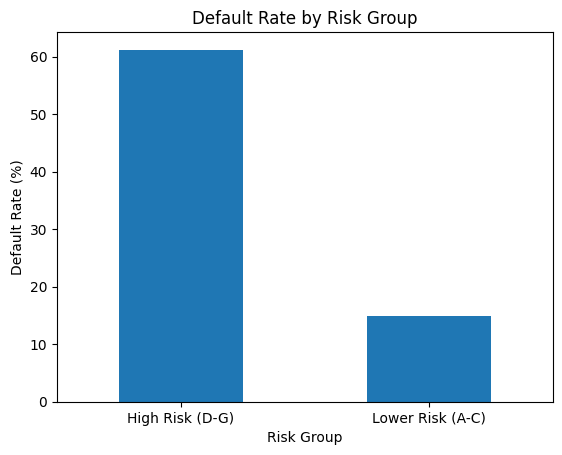

In [233]:
risk_group_default_rate.plot(kind='bar')

plt.title('Default Rate by Risk Group')
plt.xlabel('Risk Group')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [234]:
df_clean['high_loan_burden'] = df_clean['loan_percent_income'] > 0.25

df_clean[['loan_percent_income', 'high_loan_burden']].head()

,loan_percent_income,high_loan_burden
0,0.59,True
1,0.10,False
2,0.57,True
3,0.53,True
4,0.55,True


In [235]:
combined_risk = df_clean.groupby(
    ['high_loan_burden', 'cb_person_default_on_file']
)['loan_status'].mean() * 100

combined_risk

high_loan_burden  cb_person_default_on_file
False             N                            11.154393
                  Y                            30.133929
True              N                            49.890329
                  Y                            64.980237
Name: loan_status, dtype: float64

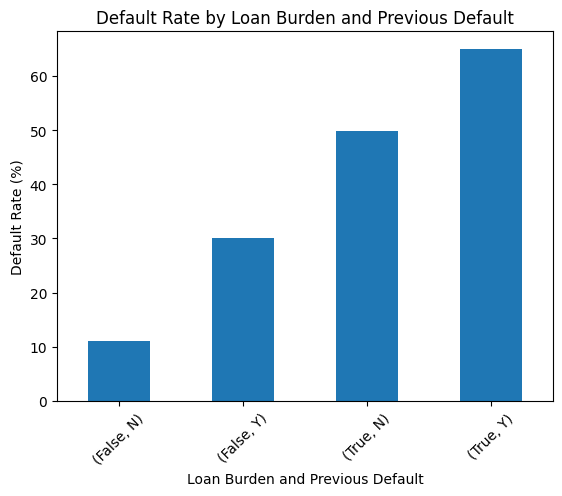

In [236]:
combined_risk.plot(kind='bar')

plt.title('Default Rate by Loan Burden and Previous Default')
plt.xlabel('Loan Burden and Previous Default')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)

plt.show()

In [237]:
high_risk_grade[
    ['person_age', 'person_income', 'person_emp_length',
     'loan_amnt', 'loan_int_rate', 'loan_percent_income']
].describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income
count,4895.000000,4895.000000,4895.000000,4895.000000,4895.000000,4895.000000
mean,27.906435,65911.906231,4.600817,11529.647600,15.477651,0.195877
std,6.405216,49083.559102,4.032662,7529.265888,2.034369,0.110644
min,20.000000,4200.000000,0.000000,1000.000000,6.000000,0.010000
25%,23.000000,36000.000000,2.000000,5500.000000,14.610000,0.110000
50%,26.000000,54400.000000,4.000000,10000.000000,15.620000,0.180000
75%,30.000000,78000.000000,7.000000,15600.000000,16.490000,0.260000
max,70.000000,703800.000000,34.000000,35000.000000,23.220000,0.700000


In [238]:
profile_comparison = df_clean.groupby(risk_group)[
    ['person_income', 'person_emp_length',
     'loan_amnt', 'loan_int_rate', 'loan_percent_income']
].mean()

profile_comparison

,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income
loan_grade,,,,,
High Risk (D-G),65911.906231,4.600817,11529.647600,15.477651,0.195877
Lower Risk (A-C),66103.657336,4.788955,9246.322148,10.219654,0.165664


In [239]:
high_risk_grade['loan_status'].value_counts()

,count
loan_status,
1,2995
0,1900


In [240]:
total_borrowers = len(df_clean)

defaulted_borrowers = df_clean['loan_status'].sum()

overall_default_rate = df_clean['loan_status'].mean() * 100

average_loan_amount = df_clean['loan_amnt'].mean()

average_interest_rate = df_clean['loan_int_rate'].mean()

print("Total Borrowers:", total_borrowers)
print("Defaulted Borrowers:", defaulted_borrowers)
print("Overall Default Rate:", overall_default_rate)
print("Average Loan Amount:", average_loan_amount)
print("Average Interest Rate:", average_interest_rate)

Total Borrowers: 32581
Defaulted Borrowers: 7108
Overall Default Rate: 21.816396059052824
Average Loan Amount: 9589.371105859243
Average Interest Rate: 11.009620023940332


In [241]:
high_risk_borrowers = len(high_risk_grade)

high_risk_percentage = (high_risk_borrowers / total_borrowers) * 100

print("High-Risk Borrowers:", high_risk_borrowers)
print("High-Risk Borrower Percentage:", high_risk_percentage)

High-Risk Borrowers: 4895
High-Risk Borrower Percentage: 15.024093796998251


In [242]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Borrowers',
        'Defaulted Borrowers',
        'Overall Default Rate (%)',
        'Average Loan Amount',
        'Average Interest Rate (%)',
        'High-Risk Borrowers',
        'High-Risk Borrower Percentage (%)'
    ],
    'Value': [
        total_borrowers,
        defaulted_borrowers,
        overall_default_rate,
        average_loan_amount,
        average_interest_rate,
        high_risk_borrowers,
        high_risk_percentage
    ]
})

kpi_summary

,KPI,Value
0,Total Borrowers,32581.000000
1,Defaulted Borrowers,7108.000000
2,Overall Default Rate (%),21.816396
3,Average Loan Amount,9589.371106
4,Average Interest Rate (%),11.009620
5,High-Risk Borrowers,4895.000000
6,High-Risk Borrower Percentage (%),15.024094


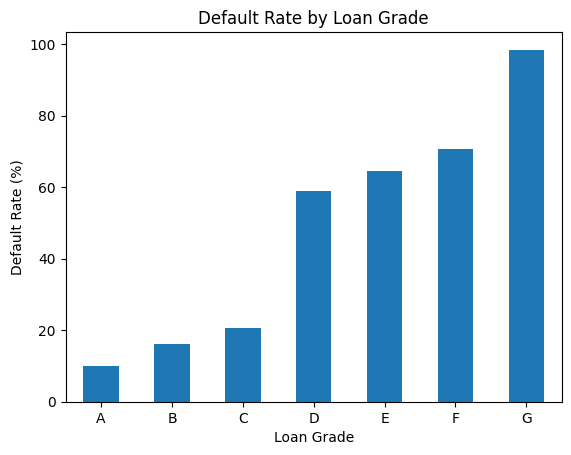

In [243]:
grade_default_rate.plot(kind='bar')

plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)

plt.show()

/tmp/ipykernel_1284/1468859149.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  burden_default_rate = df_clean.groupby(


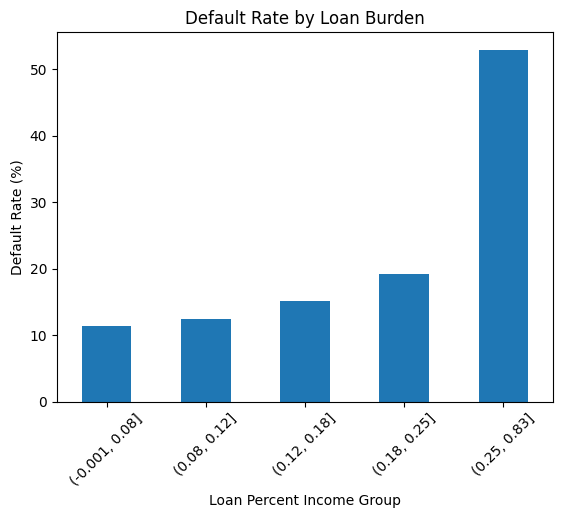

In [244]:
burden_default_rate = df_clean.groupby(
    pd.qcut(df_clean['loan_percent_income'], 5)
)['loan_status'].mean() * 100

burden_default_rate.plot(kind='bar')

plt.title('Default Rate by Loan Burden')
plt.xlabel('Loan Percent Income Group')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)

plt.show()

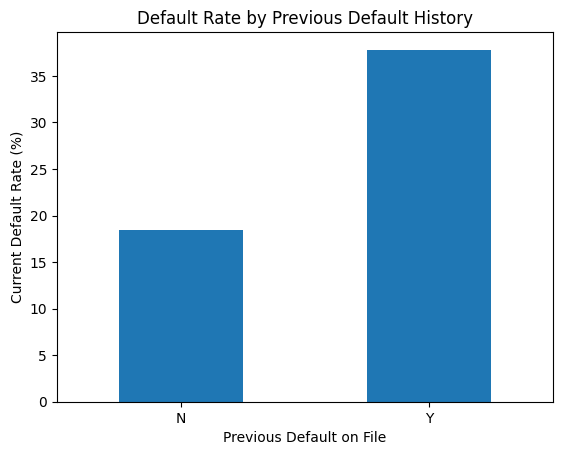

In [245]:
previous_default_rate = df_clean.groupby(
    'cb_person_default_on_file'
)['loan_status'].mean() * 100

previous_default_rate.plot(kind='bar')

plt.title('Default Rate by Previous Default History')
plt.xlabel('Previous Default on File')
plt.ylabel('Current Default Rate (%)')
plt.xticks(rotation=0)

plt.show()

/tmp/ipykernel_1284/2995942992.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interest_default_rate = df_clean.groupby(


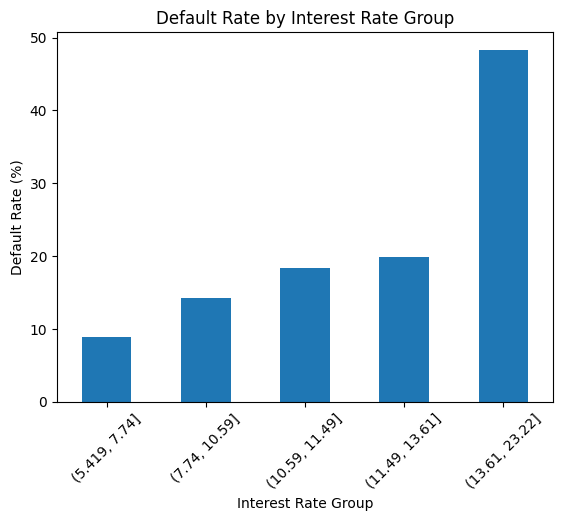

In [246]:
interest_default_rate = df_clean.groupby(
    pd.qcut(df_clean['loan_int_rate'], 5)
)['loan_status'].mean() * 100

interest_default_rate.plot(kind='bar')

plt.title('Default Rate by Interest Rate Group')
plt.xlabel('Interest Rate Group')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)

plt.show()

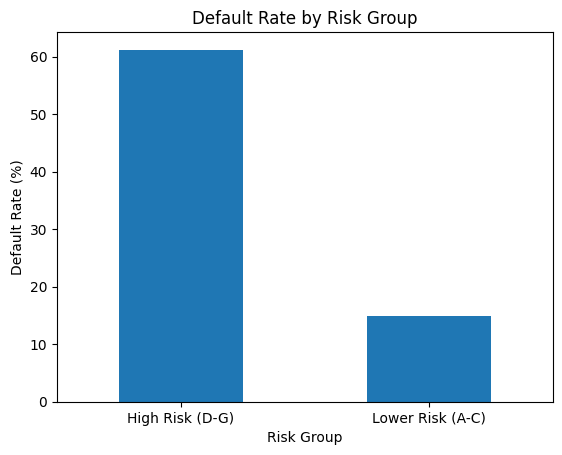

In [247]:
risk_group_default_rate.plot(kind='bar')

plt.title('Default Rate by Risk Group')
plt.xlabel('Risk Group')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [248]:
risk_summary = pd.DataFrame({
    'Risk Factor': [
        'Overall Borrowers',
        'Overall Default Rate',
        'High-Risk Grade (D-G)',
        'High-Risk Grade Default Rate',
        'High Loan Burden (>25%)',
        'Previous Default = Y'
    ],
    'Value': [
        total_borrowers,
        overall_default_rate,
        high_risk_borrowers,
        high_risk_grade_default_rate,
        df_clean[df_clean['high_loan_burden']]['loan_status'].mean() * 100,
        df_clean[df_clean['cb_person_default_on_file'] == 'Y']['loan_status'].mean() * 100
    ]
})

risk_summary

,Risk Factor,Value
0,Overall Borrowers,32581.000000
1,Overall Default Rate,21.816396
2,High-Risk Grade (D-G),4895.000000
3,High-Risk Grade Default Rate,61.184883
4,High Loan Burden (>25%),52.929936
5,Previous Default = Y,37.806789


In [249]:
df_final = df_clean.drop(columns=['high_loan_burden'])

df_final.shape

(32581, 12)

In [250]:
print("Missing values:")
print(df_final.isna().sum())

print("\nDuplicate rows:", df_final.duplicated().sum())

Missing values:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Duplicate rows: 165


In [251]:
df_final.to_csv('credit_risk_cleaned.csv', index=False)

## Key Risk Insights

1. The overall default rate in the dataset was 21.82%.

2. Borrowers in higher-risk loan grades (D-G) had a substantially higher observed default rate of 61.18%, compared with 14.86% for grades A-C.

3. Borrowers with a high loan-to-income burden (>25%) had an observed default rate of 52.93%.

4. Borrowers with a previous default record had an observed current default rate of 37.81%, compared with 18.39% for borrowers without a previous default record.

5. Higher interest-rate groups showed higher observed default rates, with the highest interest-rate group having a default rate of 48.33%.

6. Higher loan amounts were associated with somewhat higher default rates, although the relationship was less pronounced than loan burden and interest rate.

7. Default rates varied across loan purposes and home ownership categories.

8. Income showed a weak negative relationship with default status, while age showed almost no linear relationship with default status.

## Conclusion

The Credit Risk Analysis identified several borrower and loan characteristics associated with observed loan defaults.

The analysis found that higher loan grades (D-G), higher loan-to-income burden, and higher interest-rate groups were associated with substantially higher default rates. Borrowers with a previous default record also showed a higher observed current default rate.

Default rates also varied across loan purposes and home ownership categories. Income showed a weak negative relationship with default status, while age showed almost no linear relationship with default status.

Overall, this project demonstrates how Python and data analysis techniques can be used to explore credit risk patterns, perform data cleaning, calculate risk metrics, and communicate findings through visualizations.

These findings provide a foundation for further credit-risk analysis and can be extended in the future with predictive modeling or a dashboard.
